In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import i24_motion_macro
import matplotlib.pyplot as plt
import numpy
import gc
import optuna

In [3]:
def fft_four_convs(Dp, Mp, k_cong, k_free, eps=1e-12, use_ortho=True):
    """
    Compute via FFT:
        sum_cong = conv2d(Dp, k_cong)
        sum_free = conv2d(Dp, k_free)
        N_cong   = conv2d(Mp, k_cong)
        N_free   = conv2d(Mp, k_free)
    Inputs:
      Dp, Mp:   (B, C, H, W)
      k_cong,:  (F, C, Kh, Kw)
      k_free:   (F, C, Kh, Kw)
    Returns:
      sum_cong, N_cong, sum_free, N_free each of shape (B, F, H-Kh+1, W-Kw+1)
    """
    # ——— sanitize inputs ———
    Dp = torch.nan_to_num(Dp, nan=0.0, posinf=0.0, neginf=0.0)
    Mp = torch.nan_to_num(Mp, nan=0.0, posinf=0.0, neginf=0.0)

    B, C, H, W        = Dp.shape
    F, _, Kh, Kw      = k_cong.shape
    Fh, Fw            = H + Kh - 1, W + Kw - 1
    device, dtype     = Dp.device, Dp.dtype

    # ——— pad inputs ———
    Dp_pad = torch.zeros(B, C, Fh, Fw, device=device, dtype=dtype)
    Mp_pad = torch.zeros(B, C, Fh, Fw, device=device, dtype=dtype)
    Dp_pad[..., :H, :W] = Dp
    Mp_pad[..., :H, :W] = Mp

    # ——— pad kernels ———
    k1_pad = torch.zeros(F, C, Fh, Fw, device=device, dtype=dtype)
    k2_pad = torch.zeros(F, C, Fh, Fw, device=device, dtype=dtype)
    k1_pad[..., :Kh, :Kw] = k_cong
    k2_pad[..., :Kh, :Kw] = k_free

    # choose normalization
    norm = "ortho" if use_ortho else None

    # ——— FFT both inputs and kernels ———
    Df  = torch.fft.rfftn(Dp_pad, dim=(-2, -1), s=(Fh, Fw), norm=norm)
    Mf  = torch.fft.rfftn(Mp_pad, dim=(-2, -1), s=(Fh, Fw), norm=norm)
    Kf1 = torch.fft.rfftn(k1_pad, dim=(-2, -1), s=(Fh, Fw), norm=norm)
    Kf2 = torch.fft.rfftn(k2_pad, dim=(-2, -1), s=(Fh, Fw), norm=norm)

    # ——— pointwise multiply in freq domain ———
    Y1 = Df * Kf1    # for sum_cong
    Y2 = Df * Kf2    # for sum_free
    Z1 = Mf * Kf1    # for N_cong
    Z2 = Mf * Kf2    # for N_free

    # ——— inverse FFT back to real ———
    y1 = torch.fft.irfftn(Y1, dim=(-2, -1), s=(Fh, Fw), norm=norm)
    y2 = torch.fft.irfftn(Y2, dim=(-2, -1), s=(Fh, Fw), norm=norm)
    z1 = torch.fft.irfftn(Z1, dim=(-2, -1), s=(Fh, Fw), norm=norm)
    z2 = torch.fft.irfftn(Z2, dim=(-2, -1), s=(Fh, Fw), norm=norm)

    # ——— crop “valid” region ———
    oh, ow = H - Kh + 1, W - Kw + 1
    sum_cong = y1[..., Kh-1:Kh-1+oh, Kw-1:Kw-1+ow]
    sum_free = y2[..., Kh-1:Kh-1+oh, Kw-1:Kw-1+ow]
    N_cong   = z1[..., Kh-1:Kh-1+oh, Kw-1:Kw-1+ow]
    N_free   = z2[..., Kh-1:Kh-1+oh, Kw-1:Kw-1+ow]

    # ——— optional epsilon to counts to avoid zero division downstream ———
    N_cong = N_cong + eps
    N_free = N_free + eps

    return sum_cong, N_cong, sum_free, N_free

class AdaptiveSmoothing(nn.Module):
    def __init__(self,
                 kernel_time_window: float,
                 kernel_space_window: float,
                 dx: float,
                 dt: float,
                 init_delta: float = 0.02, # mile
                 init_tau: float = 4.0, # seconds
                 init_c_cong: float = 12.0,
                 init_c_free: float = -45.0,
                 init_v_thr: float = 40.0,
                 init_v_delta: float = 10.0,
                 high_is_congestion=False):
        super().__init__()
        self.size_t = int(kernel_time_window / dt)
        self.size_x = int(kernel_space_window / dx)
        self.dt = dt
        self.dx = dx

        t_offs = torch.arange(-self.size_t, self.size_t + 1) * dt
        # print(t_offs)
        x_offs = torch.arange(-self.size_x, self.size_x + 1) * dx
        # print(x_offs)
        #X, T = torch.meshgrid(x_offs, t_offs, indexing='ij')
        T, X = torch.meshgrid(t_offs, x_offs, indexing='ij')
        self.register_buffer('T_offsets', T.float())
        self.register_buffer('X_offsets', X.float())

        self.delta   = nn.Parameter(torch.tensor(init_delta))
        self.tau     = nn.Parameter(torch.tensor(init_tau))
        self.c_cong  = nn.Parameter(torch.tensor(init_c_cong))
        self.c_free  = nn.Parameter(torch.tensor(init_c_free))
        self.v_thr   = nn.Parameter(torch.tensor(init_v_thr))
        self.v_delta = nn.Parameter(torch.tensor(init_v_delta))
        self.high_is_congestion = high_is_congestion

    def forward(self, raw_data: torch.Tensor):
        # Ensure input is 4D: (B, C, T, X)
        
        if raw_data.ndim == 2:
            raw_data = raw_data.unsqueeze(0).unsqueeze(0)
        elif raw_data.ndim == 3:
            raw_data = raw_data.unsqueeze(1)

        mask = (~raw_data.isnan()).float()
        data = torch.nan_to_num(raw_data, nan=0.0)

        c_cong_s = self.c_cong #/ 3600.0 Already at meters per second
        c_free_s = self.c_free #/ 3600.0 Already at meters per second
        t_cong = self.T_offsets - self.X_offsets / c_cong_s
        t_free = self.T_offsets - self.X_offsets / c_free_s

        k_cong = torch.exp(-(t_cong.abs() / self.tau + self.X_offsets.abs() / self.delta))
        # size of k_cong
        k_free = torch.exp(-(t_free.abs() / self.tau + self.X_offsets.abs() / self.delta))

        k_cong = k_cong.unsqueeze(0).unsqueeze(0)  # (1,1,Kt,Kx)
        k_free = k_free.unsqueeze(0).unsqueeze(0)

        #pad = (self.size_t, self.size_t, self.size_x, self.size_x) # to deal with the edge effects
        pad = (self.size_x, self.size_x, self.size_t, self.size_t) # to deal with the edge effects
        Dp = F.pad(data, pad, value=0.0)
        Mp = F.pad(mask, pad, value=0.0)

        sum_cong = F.conv2d(Dp, k_cong)
        N_cong   = F.conv2d(Mp, k_cong)
        sum_free = F.conv2d(Dp, k_free)
        N_free   = F.conv2d(Mp, k_free)
        # use FFT to compute the convolutions
        #sum_cong, N_cong, sum_free, N_free = fft_four_convs(Dp, Mp, k_cong, k_free)

        v_cong = sum_cong / N_cong
        v_free = sum_free / N_free
        
        if (self.high_is_congestion):
            v_max = torch.max(v_cong, v_free)
            w = 0.5 * (1 + torch.tanh((v_max - self.v_thr) / self.v_delta))
            v = w * v_cong + (1 - w) * v_free
        else:
            v_min = torch.min(v_cong, v_free)
            w = 0.5 * (1 + torch.tanh((self.v_thr - v_min) / self.v_delta))
            v = w * v_cong + (1 - w) * v_free

        valid_cong = (N_cong > 0).float()
        valid_free = (N_free > 0).float()
        # if no cong data → use free; if no free data → use cong
        v = valid_cong*valid_free*v + (1-valid_cong)*v_free + (1-valid_free)*v_cong
        # check if there's nan if so print
        if torch.isnan(v).any():
            print("Warning! NaN detected in output")
            print(N_cong)
        # print size of v
        return v.squeeze(1)


In [4]:
i24macro = i24_motion_macro.I24MotionMacro(i24_motion_macro.i24_motion_data.I24MotionData(2, 1669812350, 1669812350+3600, 0, 1600), 2, "road_2", longitudinal_cell_size=50.0, time_delta=0.5)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [5]:
raw_macro = i24macro.loadRawMacroData()

In [6]:
queries = i24macro.computeEdieBoxQueries()

In [6]:
raw_macro[-1]['density'].shape

(230400,)

In [7]:
density_result, velocity_result, flow_result = raw_macro[-1]["density"], raw_macro[-1]["velocity"], raw_macro[-1]["flow"]
velocity_result_mask = ~numpy.isnan(velocity_result)
density_result_stat = density_result[velocity_result_mask]
velocity_result_stat = velocity_result[velocity_result_mask]
flow_result_stat = flow_result[velocity_result_mask]
print(density_result_stat.min(), density_result_stat.mean(), density_result_stat.max(), density_result_stat.std())
print(velocity_result_stat.min(), velocity_result_stat.mean(), velocity_result_stat.max(), velocity_result_stat.std())
print(flow_result_stat.min(), flow_result_stat.mean(), flow_result_stat.max(), flow_result_stat.std())
print(density_result.shape, velocity_result.shape, flow_result.shape)

0.0 0.035804037 0.18 0.024590801
0.0 28.159725 45.0 17.520966
0.0 0.99691653 6.3 0.7079996
(230400,) (230400,) (230400,)


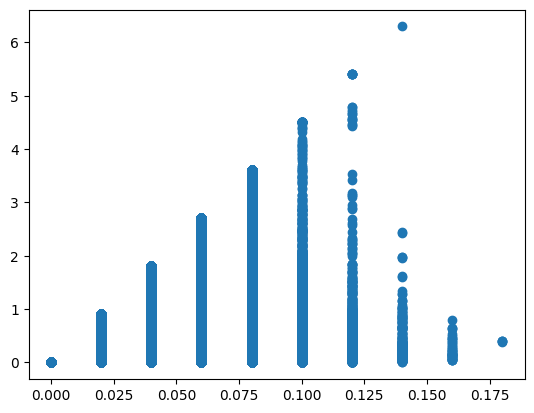

In [8]:
plt.scatter(density_result, flow_result)

In [9]:
p = numpy.polyfit(density_result_stat, flow_result_stat, deg=2)

In [10]:
p

array([-4.23865599e+02,  5.00702350e+01,  3.88044227e-03])

In [11]:
density_range = numpy.arange(0, 0.15, 0.001)
def polyfunction(p, d):
    return (p[0] * (d ** 2.0)) + (p[1] * d) + p[2]

estimated_flow = numpy.array([polyfunction(p, d) for d in density_range])

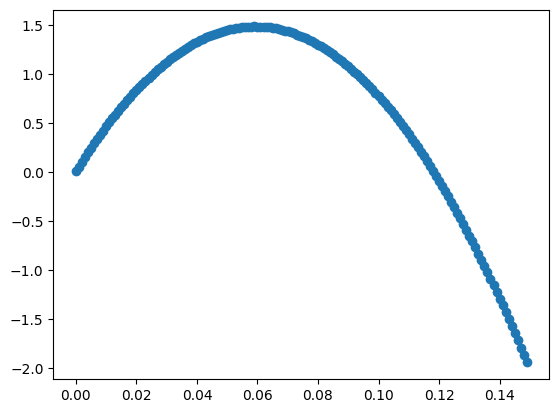

In [12]:
plt.scatter(density_range, estimated_flow)

In [13]:
p = numpy.polyfit(velocity_result_stat, flow_result_stat, deg=2)
velocity_range = numpy.arange(0, 90.0, 0.01)
def polyfunction(p, d):
    return  (p[0] * (d ** 2.0)) + (p[1] * d) + p[2]

estimated_flow = numpy.array([polyfunction(p, d) for d in velocity_range])

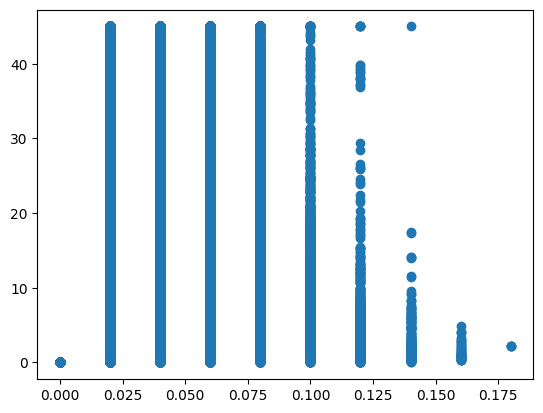

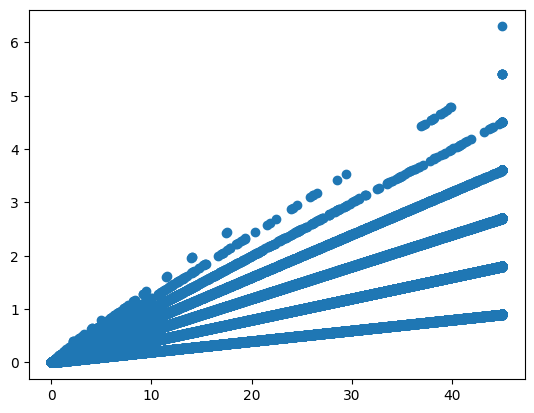

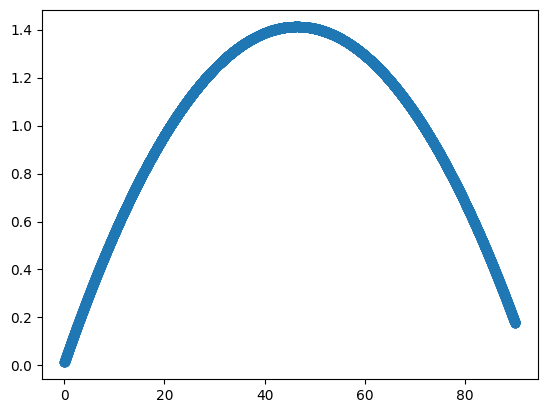

In [14]:
plt.scatter(density_result_stat, velocity_result_stat)
plt.show()
plt.scatter(velocity_result_stat, flow_result_stat)
plt.show()
plt.scatter(velocity_range, estimated_flow)
plt.show()

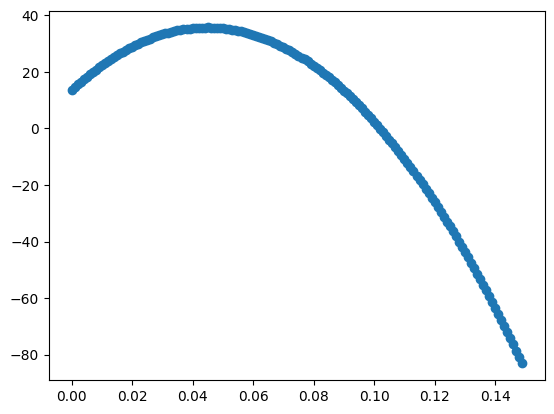

In [15]:
p = numpy.polyfit(density_result_stat, velocity_result_stat, deg=2)
density_range = numpy.arange(0, 0.15, 0.001)
def polyfunction(p, d):
    return (p[0] * (d ** 2.0)) + (p[1] * d) + p[2]

estimated_velocity = numpy.array([polyfunction(p, d) for d in density_range])
plt.scatter(density_range, estimated_velocity)
plt.show()


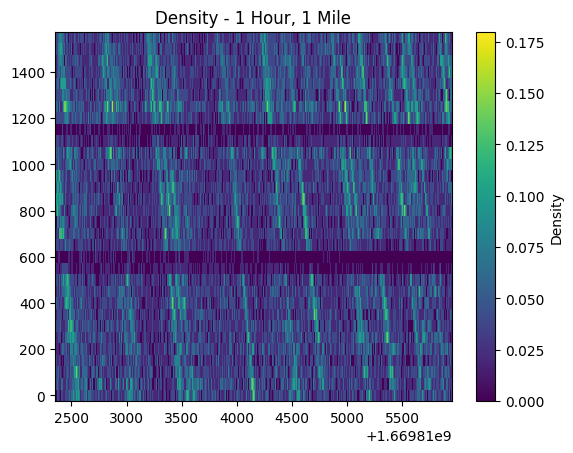

In [16]:
timestamp_min_display = numpy.array(queries["timestamp_min"]).reshape((7200, 32)).T
s_min_display = numpy.array(queries["s_min"]).reshape((7200, 32)).T
density_result_display = density_result.reshape((7200, 32)).T
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto')
plt.title('Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

In [17]:
print(min(queries["s_min"]), max(queries["s_max"]))

0.0 1600.0


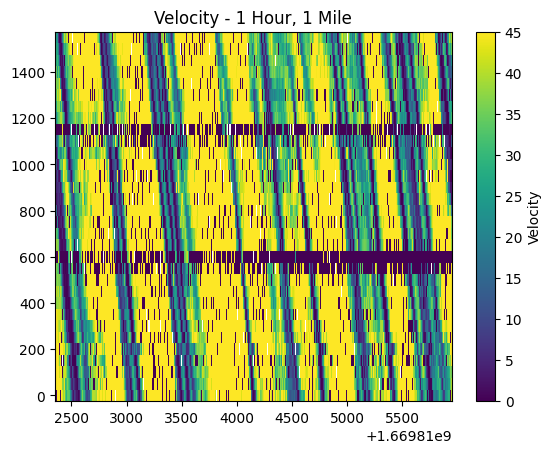

In [18]:
timestamp_min_display = numpy.array(queries["timestamp_min"]).reshape((7200, 32)).T
s_min_display = numpy.array(queries["s_min"]).reshape((7200, 32)).T
velocity_result_display = velocity_result.reshape((7200, 32)).T
plt.pcolormesh(timestamp_min_display, s_min_display, velocity_result_display, cmap='viridis', shading='auto')
plt.title('Velocity - 1 Hour, 1 Mile')
plt.colorbar(label='Velocity')
plt.show()

In [26]:
#del velocity_result_asm_output
#del density_result_asm_output
#gc.collect()
velocity_result_asm_input = velocity_result.reshape((1, 1, 7200, 32)).copy()
velocity_result_asm_input[velocity_result_asm_input == 0] = numpy.nan
velocity_result_asm_input = torch.from_numpy(velocity_result_asm_input).to("cuda")
"""init_delta: float = 32.0, # meters
init_tau: float = 4.0, # seconds
init_c_cong: float = -5.36, # Meters per second going backwards
init_c_free: float = 20.00 # Meters per second going forwards
init_v_thr: float = 17.00, # Meters per second
init_v_delta: float = 4.5 # Meters per second"""
"""
{'init_c_cong': -4.386450786436988,
 'init_c_free': 41.09152765794657,
 'init_delta': 105.62640175480215,
 'init_tau': 0.1052379737326149,
 'v_thr': 0.0609944197208978,
 'v_delta': 0.03731597995330584}
 """

"""
{'init_c_cong': -4.435442333413168,
 'init_c_free': 31.835619183232694,
 'v_thr': 0.062871015625177,
 'v_delta': 0.005002742521751672}
"""

asm = AdaptiveSmoothing(3600.0, 1600.0, dx=50.0, dt=0.5, init_delta=105.62640175480215, init_tau=0.1052379737326149, init_c_cong=-4.435442333413168, init_c_free=31.835619183232694, init_v_thr=29.99849306345678, init_v_delta=9.989311356689827).to("cuda")
#asm = AdaptiveSmoothing(3600.0, 1600.0, dx=50.0, dt=0.5, init_delta=10.197239034761685, init_tau=0.6226188217629887, init_c_cong=-5.36, init_c_free=45.0, init_v_thr=10.55926695516419, init_v_delta=1.1422346804487675).to("cuda")
#asm = AdaptiveSmoothing(3600.0, 1600.0, dx=50.0, dt=0.5, init_delta=7.347636200013352, init_tau=0.10218764308860165, init_c_cong=-5.36, init_c_free=45.0, init_v_thr=22.483863199256756, init_v_delta=4.748832222214532).to("cuda")
#asm = AdaptiveSmoothing(3600.0, 1600.0, dx=50.0, dt=0.5, init_delta=1.0903570129365505, init_tau=0.1004015788506238, init_c_cong=-5.36, init_c_free=45.0, init_v_thr=26.671108031058232, init_v_delta=3.760697346179693).to("cuda")
velocity_result_asm_output = asm(velocity_result_asm_input)

In [20]:
velocity_result_asm_output.shape

torch.Size([1, 7200, 32])

(32, 7200)
0.14787787 32.39238 45.000023 13.45298
0.0 28.159723 45.0 17.520967
(32, 7200) (32, 7200)


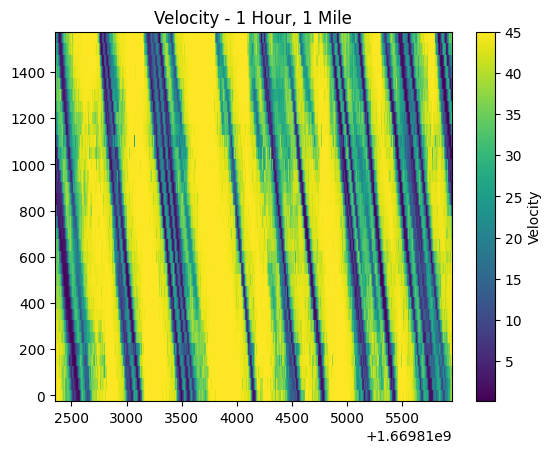

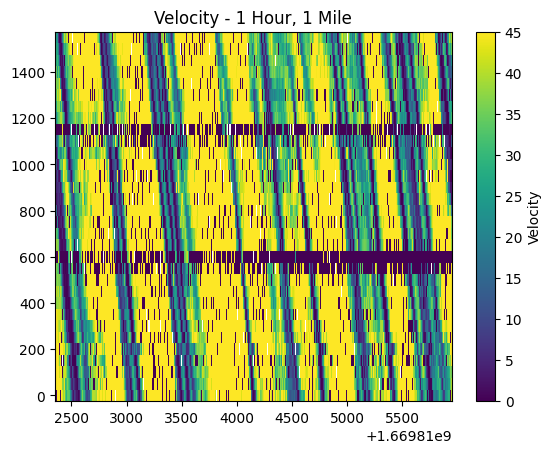

In [27]:
velocity_result_asm_output_display = (velocity_result_asm_output.cpu().detach().numpy()).reshape(7200, 32).T
print(velocity_result_asm_output_display.shape)
print(velocity_result_asm_output_display.min(), velocity_result_asm_output_display.mean(), velocity_result_asm_output_display.max(), velocity_result_asm_output_display.std())
velocity_result_display_stat = velocity_result_display[~numpy.isnan(velocity_result_display)]
print(velocity_result_display_stat.min(), velocity_result_display_stat.mean(), velocity_result_display_stat.max(), velocity_result_display_stat.std())
print(velocity_result_asm_output_display.shape, velocity_result_display.shape)
plt.pcolormesh(timestamp_min_display, s_min_display, velocity_result_asm_output_display, cmap='viridis', shading='auto')
plt.title('Velocity - 1 Hour, 1 Mile')
plt.colorbar(label='Velocity')
plt.show()
plt.pcolormesh(timestamp_min_display, s_min_display, velocity_result_display, cmap='viridis', shading='auto')
plt.title('Velocity - 1 Hour, 1 Mile')
plt.colorbar(label='Velocity')
plt.show()

In [29]:
#del velocity_result_asm_output
#del density_result_asm_output
gc.collect()
density_result_asm_input = density_result.reshape((1, 1, 7200, 32)).copy()
density_result_asm_input[velocity_result_asm_input.cpu().numpy() == 0] = numpy.nan
density_result_asm_input = torch.from_numpy(density_result_asm_input).to("cuda")
"""init_delta: float = 32.0, # meters
init_tau: float = 4.0, # seconds
init_c_cong: float = -5.36, # Meters per second going backwards
init_c_free: float = 20.00 # Meters per second going forwards
init_v_thr: float = 0.1, # vehicles per meter
init_v_delta: float = 0.02 # vehicles per meter"""

asm = AdaptiveSmoothing(3600.0, 1600.0, dx=50.0, dt=0.5, init_delta=20.0, init_tau=4.0, init_c_cong=-4.435442333413168, init_c_free=31.835619183232694, init_v_thr=0.0609944197208978, init_v_delta=0.03731597995330584, high_is_congestion=True).to("cuda")
density_result_asm_output = asm(density_result_asm_input)

(32, 7200)
0.0 0.035678037 0.18 0.024530653
0.0009784162 0.035707973 0.13072403 0.018592713


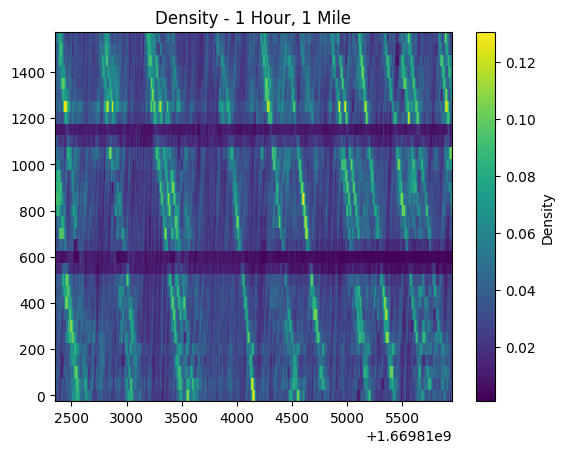

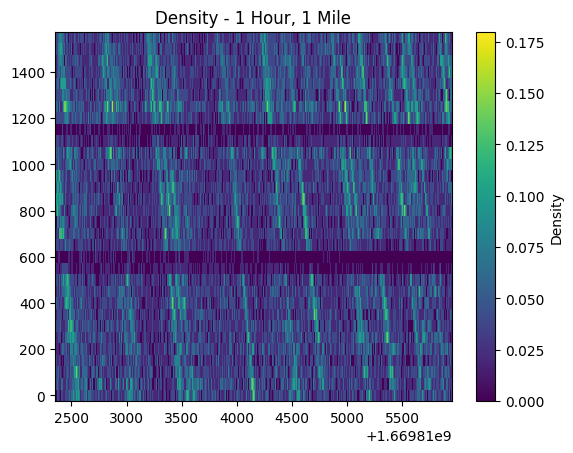

In [30]:
density_result_asm_output_display = (density_result_asm_output.cpu().detach().numpy()).reshape(7200, 32).T
print(density_result_asm_output_display.shape)
density_result_display_stat = density_result_display[~numpy.isnan(density_result_display)]
print(density_result_display_stat.min(), density_result_display_stat.mean(), density_result_display_stat.max(), density_result_display_stat.std())
print(density_result_asm_output_display.min(), density_result_asm_output_display.mean(), density_result_asm_output_display.max(), density_result_asm_output_display.std())
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_asm_output_display, cmap='viridis', shading='auto')
plt.title('Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto')
plt.title('Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

In [ ]:
def objective(trial):
    #init_delta = trial.suggest_float('init_delta', 1.0, 20.0)
    #init_tau = trial.suggest_float('init_tau', 1.0, 5.0)
    init_c_cong = -6.2
    init_c_free = 42.0
    init_delta = 100.0
    init_tau = 0.12
    #init_delta = trial.suggest_float('init_delta', 1.0, 20.0)
    #init_tau = trial.suggest_float('init_tau', 0.1, 15.0)
    v_thr = trial.suggest_float('v_thr', 10.0, 30.0)
    v_delta = trial.suggest_float('v_delta', 0.5, 10.0)
    #v_thr = 15.00048812939796
    #v_delta = 2.85162298360557
    velocity_result_asm_input = velocity_result.reshape((1, 1, 7200, 32)).copy()
    velocity_result_asm_input[velocity_result_asm_input == 0] = numpy.nan
    velocity_result_asm_input = numpy.clip(velocity_result_asm_input, 0, 45.0)
    rng = numpy.random.default_rng(seed=42)
    noise = rng.normal(loc=0.0, scale=5.0, size=velocity_result_asm_input.shape)
    velocity_result_asm_input_noised = velocity_result_asm_input + noise
    velocity_result_asm_input_noised = numpy.clip(velocity_result_asm_input_noised, 0, 45.0)
    
    velocity_result_asm_input_noised = torch.from_numpy(velocity_result_asm_input_noised).to("cuda").to(torch.float32)
    """init_delta: float = 32.0, # meters
    init_tau: float = 4.0, # seconds
    init_c_cong: float = -5.36, # Meters per second going backwards
    init_c_free: float = 20.00 # Meters per second going forwards
    init_v_thr: float = 17.00, # Meters per second
    init_v_delta: float = 4.5 # Meters per second"""
    #asm = AdaptiveSmoothing(3600.0, 1600.0, dx=50.0, dt=0.5, init_delta=20.0, init_tau=4.0, init_c_cong=-4.435442333413168, init_c_free=31.835619183232694, init_v_thr=10.55926695516419, init_v_delta=1.1422346804487675).to("cuda")
    asm = AdaptiveSmoothing(3600.0, 1600.0, dx=50.0, dt=0.5, init_delta=init_delta, init_tau=init_tau, init_c_cong=init_c_cong, init_c_free=init_c_free, init_v_thr=v_thr, init_v_delta=v_delta).to("cuda")
    velocity_result_asm_output = asm(velocity_result_asm_input_noised)
    velocity_base_stat = numpy.nan_to_num(velocity_result)
    mae = (abs((velocity_result_asm_output.cpu().detach().numpy().reshape(-1) - velocity_base_stat)) / (7200.0 * 32.0)).sum() 
    std_dev_deviation = abs(velocity_base_stat.std() - velocity_result_asm_output.cpu().detach().numpy().reshape(-1).std())
    print(mae, std_dev_deviation)
    return mae + std_dev_deviation
    

study = optuna.create_study()
study.optimize(objective, n_trials=250)

study.best_params

[I 2026-03-26 01:32:25,209] A new study created in memory with name: no-name-87c46368-ff14-423a-ba54-bb8adf6b63a4
[I 2026-03-26 01:32:26,073] Trial 0 finished with value: 12.737751007080078 and parameters: {'v_thr': 15.870429181297002, 'v_delta': 8.056238884561344}. Best is trial 0 with value: 12.737751007080078.


7.602013 5.1357374


[I 2026-03-26 01:32:26,924] Trial 1 finished with value: 12.547069549560547 and parameters: {'v_thr': 22.183749421948832, 'v_delta': 6.926544375854244}. Best is trial 1 with value: 12.547069549560547.


7.5209994 5.0260706


[I 2026-03-26 01:32:27,794] Trial 2 finished with value: 12.575215339660645 and parameters: {'v_thr': 15.659960661940772, 'v_delta': 1.7473739812988516}. Best is trial 1 with value: 12.547069549560547.


...

[I 2026-03-26 01:36:03,196] Trial 248 finished with value: 12.447052955627441 and parameters: {'v_thr': 29.02672898340042, 'v_delta': 9.81075344791277}. Best is trial 220 with value: 12.426359176635742.


7.455282 4.9917707


[I 2026-03-26 01:36:04,072] Trial 249 finished with value: 12.505727767944336 and parameters: {'v_thr': 29.983756656309804, 'v_delta': 1.396270499153669}. Best is trial 220 with value: 12.426359176635742.


7.5127196 4.9930086


{'v_thr': 29.99849306345678, 'v_delta': 9.989311356689827}

In [201]:
study.best_params

{'v_thr': 29.99849306345678, 'v_delta': 9.989311356689827}

In [ ]:
def objective(trial):
    #init_delta = trial.suggest_float('init_delta', 1.0, 20.0)
    #init_tau = trial.suggest_float('init_tau', 1.0, 5.0)
    #init_delta = 20.0
    #init_tau = 0.5
    #init_c_cong = trial.suggest_float('init_c_cong', -8.0, -4.0)
    #init_c_free = trial.suggest_float('init_c_free', 30.0, 45.0)
    init_c_cong = -6.2
    init_c_free = 42.0
    init_delta = 100.0
    init_tau = 0.12
    #init_tau = 4.0
    #init_delta = trial.suggest_float('init_delta', 80.0, 250.0)
    #init_tau = trial.suggest_float('init_tau', 0.1, 30.0)
    #init_delta = 1.0903570129365505
    #init_tau = 0.1004015788506238
    v_thr = trial.suggest_float('v_thr', 0.04, 0.12)
    v_delta = trial.suggest_float('v_delta', 0.005, 0.04)
    #v_thr = 15.00048812939796
    #v_delta = 2.85162298360557
    density_result_asm_input = density_result.reshape((1, 1, 7200, 32)).copy()
    density_result_asm_input[density_result_asm_input == 0] = numpy.nan
    density_result_asm_input = numpy.clip(density_result_asm_input, 0, 0.2)
    rng = numpy.random.default_rng(seed=42)
    noise = rng.normal(loc=0.0, scale=0.05, size=density_result_asm_input.shape)
    density_result_asm_input_noised = density_result_asm_input + noise
    density_result_asm_input_noised = numpy.clip(density_result_asm_input_noised, 0, 0.2)
    
    density_result_asm_input_noised = torch.from_numpy(density_result_asm_input_noised).to("cuda").to(torch.float32)
    """init_delta: float = 32.0, # meters
    init_tau: float = 4.0, # seconds
    init_c_cong: float = -5.36, # Meters per second going backwards
    init_c_free: float = 20.00 # Meters per second going forwards
    init_v_thr: float = 17.00, # Meters per second
    init_v_delta: float = 4.5 # Meters per second"""
    asm = AdaptiveSmoothing(3600.0, 1600.0, dx=50.0, dt=0.5, init_delta=init_delta, init_tau=init_tau, init_c_cong=init_c_cong, init_c_free=init_c_free, init_v_thr=v_thr, init_v_delta=v_delta, high_is_congestion=True).to("cuda")
    density_result_asm_output = asm(density_result_asm_input_noised)
    density_base_stat = numpy.nan_to_num(density_result)
    mae = (abs((density_result_asm_output.cpu().detach().numpy().reshape(-1) - density_base_stat)) / (7200.0 * 32.0)).sum() 
    std_dev_deviation = abs(density_base_stat.std() - density_result_asm_output.cpu().detach().numpy().reshape(-1).std())
    print(mae, std_dev_deviation)
    return mae + std_dev_deviation
    

study = optuna.create_study()
study.optimize(objective, n_trials=250)

study.best_params

[I 2026-03-26 03:50:23,510] A new study created in memory with name: no-name-b1adf15f-6bf0-4e52-b8a4-7e9ed39237de
[I 2026-03-26 03:50:24,374] Trial 0 finished with value: 0.023383082821965218 and parameters: {'v_thr': 0.054298456496218325, 'v_delta': 0.034630585696937055}. Best is trial 0 with value: 0.023383082821965218.


0.02221066 0.0011724234


[I 2026-03-26 03:50:25,232] Trial 1 finished with value: 0.02372646890580654 and parameters: {'v_thr': 0.10519238683707599, 'v_delta': 0.033355070232483346}. Best is trial 0 with value: 0.023383082821965218.


0.022774566 0.00095190294


[I 2026-03-26 03:50:26,090] Trial 2 finished with value: 0.023572249338030815 and parameters: {'v_thr': 0.09843606143638972, 'v_delta': 0.01233966133857816}. Best is trial 0 with value: 0.023383082821965218.


...

0.022256564 0.00075637177


[I 2026-03-26 03:51:40,793] Trial 88 finished with value: 0.023497162386775017 and parameters: {'v_thr': 0.0923716137372794, 'v_delta': 0.007541180171174211}. Best is trial 80 with value: 0.0229193102568388.


0.022897651 0.00059951097


[I 2026-03-26 03:51:41,679] Trial 89 finished with value: 0.022956231608986855 and parameters: {'v_thr': 0.04240539649689265, 'v_delta': 0.009154940633339815}. Best is trial 80 with value: 0.0229193102568388.


0.022266496 0.00068973564


In [33]:
study.best_params

{'init_c_cong': -6.198183026328624,
 'init_c_free': 41.98866693533219,
 'init_tau': 0.11593950467444183,
 'v_thr': 0.04459888655596795,
 'v_delta': 0.006271360830306915}